In [1]:
import numpy as np
import pandas as pd

# For x_t > 0: linear x_{t+1}/x_t = r; nonlinear x_{t+1}/x_t = r(1-x_t).
# In the nonlinear rule, the proportional factor depends on the current state.
def logistic_curve(x, r):
    return r * x * (1 - x)

r_value = 2.5
x_values = np.linspace(0, 1, 400)

df_rule = pd.DataFrame({
    'x_t': x_values,
    'x_next': logistic_curve(x_values, r_value),
    'r': r_value
})

df_rule


,x_t,x_next,r
0,0.000000,0.000000,2.5
1,0.002506,0.006250,2.5
2,0.005013,0.012469,2.5
3,0.007519,0.018656,2.5
4,0.010025,0.024811,2.5
...,...,...,...
395,0.989975,0.024811,2.5
396,0.992481,0.018656,2.5
397,0.994987,0.012469,2.5
398,0.997494,0.006250,2.5


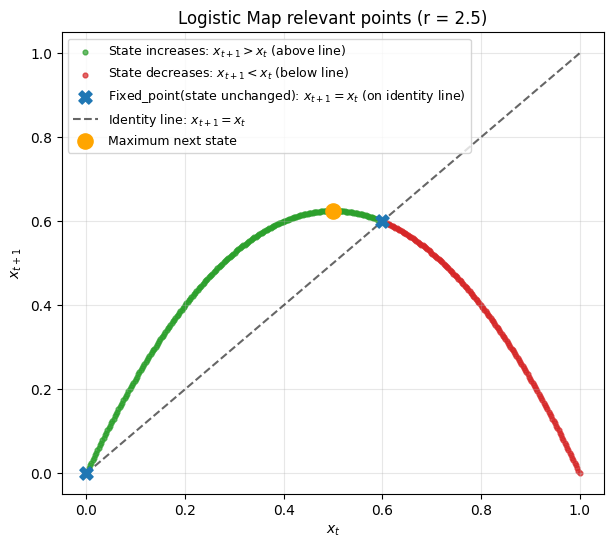

In [4]:
import matplotlib.pyplot as plt

# ---- Plot: x_t vs x_{t+1} ----
plt.figure(figsize=(7, 6))

# Compare the next state with the current state (the identity line).
x_star = 1 - 1 / r_value
# Include the exact states where x_{t+1} = x_t.
x_plot = np.unique(np.append(df_rule['x_t'].to_numpy(), [0, x_star]))
y_plot = logistic_curve(x_plot, r_value)
unchanged = np.isclose(y_plot, x_plot, rtol=0, atol=1e-12)
increases = (y_plot > x_plot) & ~unchanged
decreases = (y_plot < x_plot) & ~unchanged

plt.scatter(x_plot[increases], y_plot[increases], s=12, alpha=0.7,
            color="tab:green", label=r"State increases: $x_{t+1}>x_t$ (above line)")
plt.scatter(x_plot[decreases], y_plot[decreases], s=12, alpha=0.7,
            color="tab:red", label=r"State decreases: $x_{t+1}<x_t$ (below line)")
plt.scatter(x_plot[unchanged], y_plot[unchanged], s=90, marker="X",
            color="tab:blue", zorder=4,
            label=r"Fixed_point(state unchanged): $x_{t+1}=x_t$ (on identity line)")

# 45-degree line (identity)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6,
         label=r"Identity line: $x_{t+1}=x_t$")

# Maximum next state (maximum of parabola)
x_peak = 0.5
y_peak = r_value / 4
plt.scatter([x_peak], [y_peak], color="orange", s=120, marker="o",
            label="Maximum next state", zorder=5)

# -----------------------------
# Labels and layout
# -----------------------------
plt.xlabel(r"$x_t$")
plt.ylabel(r"$x_{t+1}$")
plt.title(rf"Logistic Map relevant points (r = {r_value})")

plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.show()
